<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/ANOVA_Penguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# 1. IMPORTAR LIBRERÍAS Y CARGAR DATASET

import seaborn as sns
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Cargar dataset Penguins
penguins = sns.load_dataset("penguins")

# Mostrar primeras filas
display(penguins.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# 2. LIMPIEZA DE DATOS
# ---------------------------------------------
penguins = penguins.dropna(subset=["species", "body_mass_g"])

# Agrupar por especie para revisar
print("\nPromedios por especie:")
display(penguins.groupby("species")["body_mass_g"].mean())


Promedios por especie:


,body_mass_g
species,
Adelie,3700.662252
Chinstrap,3733.088235
Gentoo,5076.016260


In [4]:
# 3. ANOVA DE UNA VÍA
# ---------------------------------------------
adelie = penguins[penguins["species"] == "Adelie"]["body_mass_g"]
chinstrap = penguins[penguins["species"] == "Chinstrap"]["body_mass_g"]
gentoo = penguins[penguins["species"] == "Gentoo"]["body_mass_g"]

# Prueba ANOVA
f_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)

print("\n=== RESULTADOS ANOVA ===")
print(f"F = {f_stat:.4f}")
print(f"p-value = {p_value:.6f}")


=== RESULTADOS ANOVA ===
F = 343.6263
p-value = 0.000000


In [6]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Modelo ANOVA
modelo = ols("body_mass_g ~ C(species)", data=penguins).fit()

# Tabla ANOVA completa
anova_tabla = sm.stats.anova_lm(modelo, typ=2)

display(anova_tabla)

,sum_sq,df,F,PR(>F)
C(species),1.468642e+08,2.0,343.626275,2.892368e-82
Residual,7.244348e+07,339.0,NaN,NaN


In [7]:
# Interpretación automática
alpha = 0.05
if p_value < alpha:
    print("\nConclusión: Existen diferencias estadísticamente significativas entre las especies.")
else:
    print("\nConclusión: NO se encontraron diferencias significativas.")


Conclusión: Existen diferencias estadísticamente significativas entre las especies.


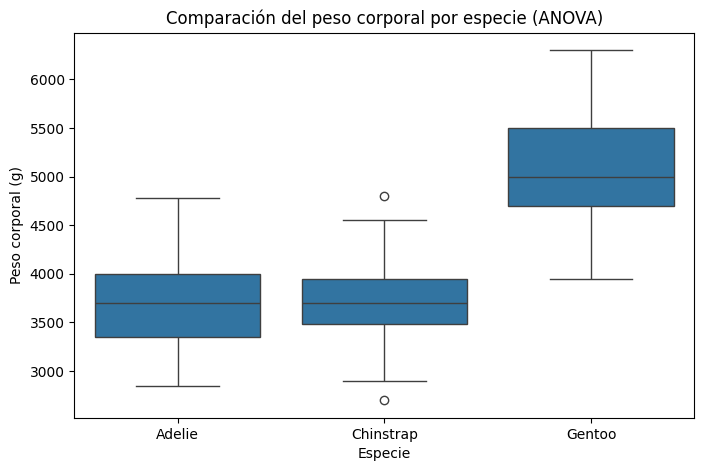

In [8]:
# 4. VISUALIZACIÓN
# ---------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins, x="species", y="body_mass_g")
plt.title("Comparación del peso corporal por especie (ANOVA)")
plt.xlabel("Especie")
plt.ylabel("Peso corporal (g)")
plt.show()